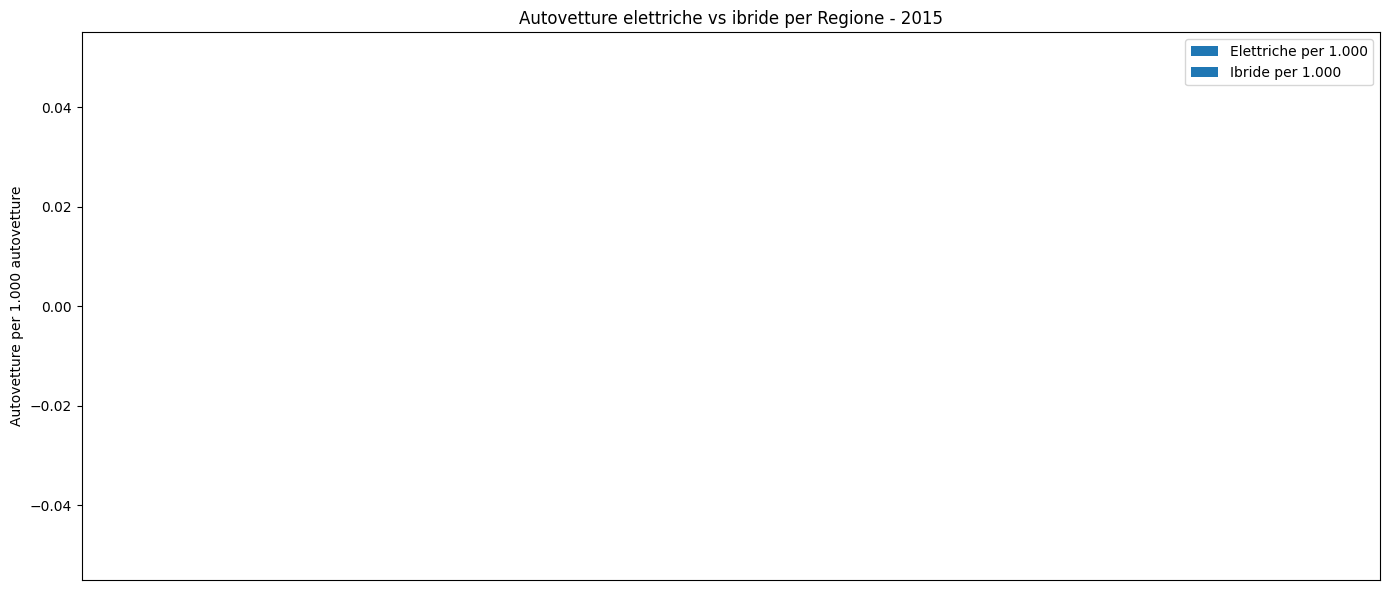

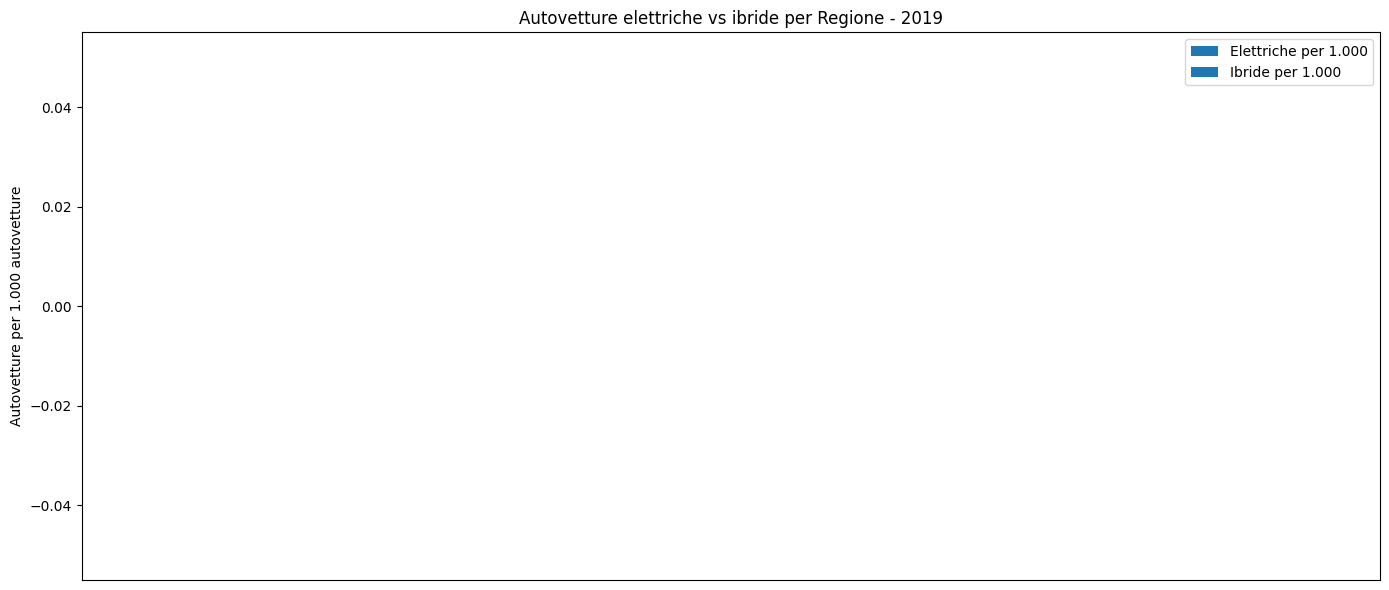

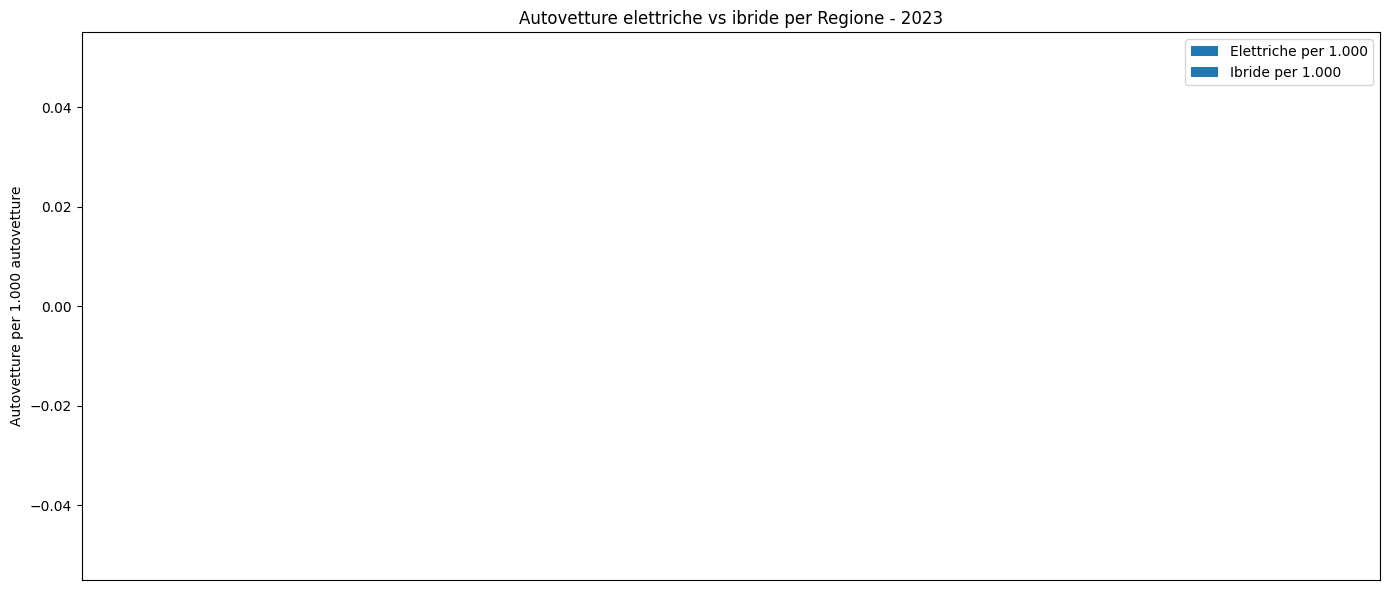

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. Lettura dei dati
# ==============================
file_elettriche = "../data/csv/auto_elettr_su_1000.csv"
file_ibride = "../data/csv/auto_ibride_su_1000.csv"

df_el = pd.read_csv(file_elettriche)
df_hy = pd.read_csv(file_ibride)

# ==============================
# 2. Filtra solo le province (esclusi Italia, Nord, ecc.)
# ==============================
valori_da_escludere = [
    'Italia', 'Nord', 'Nord-ovest', 'Nord-est', 'Centro', 'Sud', 'Mezzogiorno', 'Isole',
    'Capoluoghi di città metropolitana', 'Capoluoghi di provincia'
]

df_el_prov = df_el[~df_el['Frequenza'].isin(valori_da_escludere)].copy()
df_hy_prov = df_hy[~df_hy['Frequenza'].isin(valori_da_escludere)].copy()

# ==============================
# 3. Mapping provincia -> regione
#    (ripreso/esteso dal tuo .ipynb di esempio)
# ==============================
provincia_regione = {
    # Piemonte
    'Torino': 'Piemonte', 'Vercelli': 'Piemonte', 'Novara': 'Piemonte', 'Cuneo': 'Piemonte',
    'Asti': 'Piemonte', 'Alessandria': 'Piemonte', 'Biella': 'Piemonte', 'Verbania': 'Piemonte',

    # Valle d'Aosta
    "Aosta": "Valle d'Aosta",

    # Liguria
    'Imperia': 'Liguria', 'Savona': 'Liguria', 'Genova': 'Liguria', 'La Spezia': 'Liguria',

    # Lombardia
    'Varese': 'Lombardia', 'Como': 'Lombardia', 'Lecco': 'Lombardia', 'Sondrio': 'Lombardia',
    'Milano': 'Lombardia', 'Bergamo': 'Lombardia', 'Brescia': 'Lombardia', 'Pavia': 'Lombardia',
    'Cremona': 'Lombardia', 'Mantova': 'Lombardia', 'Monza': 'Lombardia', 'Lodi': 'Lombardia',

    # Trentino-Alto Adige
    'Bolzano/Bozen': 'Trentino-Alto Adige', 'Trento': 'Trentino-Alto Adige',

    # Veneto
    'Belluno': 'Veneto', 'Treviso': 'Veneto', 'Venezia': 'Veneto', 'Padova': 'Veneto',
    'Rovigo': 'Veneto', 'Verona': 'Veneto', 'Vicenza': 'Veneto',

    # Friuli-Venezia Giulia
    'Pordenone': 'Friuli-Venezia Giulia', 'Udine': 'Friuli-Venezia Giulia',
    'Gorizia': 'Friuli-Venezia Giulia', 'Trieste': 'Friuli-Venezia Giulia',

    # Emilia-Romagna
    "Piacenza": "Emilia-Romagna", "Parma": "Emilia-Romagna", "Reggio nell'Emilia": "Emilia-Romagna",
    "Modena": "Emilia-Romagna", "Bologna": "Emilia-Romagna", "Ferrara": "Emilia-Romagna",
    "Ravenna": "Emilia-Romagna", "Forlì": "Emilia-Romagna", "Cesena": "Emilia-Romagna",
    "Rimini": "Emilia-Romagna",

    # Toscana
    "Massa-Carrara": "Toscana", "Lucca": "Toscana", "Pistoia": "Toscana", "Firenze": "Toscana",
    "Livorno": "Toscana", "Pisa": "Toscana", "Arezzo": "Toscana", "Siena": "Toscana",
    "Grosseto": "Toscana", "Prato": "Toscana",

    # Umbria
    "Perugia": "Umbria", "Terni": "Umbria",

    # Marche
    "Pesaro e Urbino": "Marche", "Ancona": "Marche", "Macerata": "Marche",
    "Ascoli Piceno": "Marche", "Fermo": "Marche",

    # Lazio
    "Viterbo": "Lazio", "Rieti": "Lazio", "Roma": "Lazio", "Latina": "Lazio", "Frosinone": "Lazio",

    # Abruzzo
    "L'Aquila": "Abruzzo", "Teramo": "Abruzzo", "Pescara": "Abruzzo", "Chieti": "Abruzzo",

    # Molise
    "Campobasso": "Molise", "Isernia": "Molise",

    # Campania
    "Caserta": "Campania", "Benevento": "Campania", "Napoli": "Campania",
    "Avellino": "Campania", "Salerno": "Campania",

    # Puglia
    "Foggia": "Puglia", "Bari": "Puglia", "Taranto": "Puglia", "Brindisi": "Puglia",
    "Lecce": "Puglia", "Barletta-Andria-Trani": "Puglia",

    # Basilicata
    "Potenza": "Basilicata", "Matera": "Basilicata",

    # Calabria
    "Cosenza": "Calabria", "Catanzaro": "Calabria", "Reggio di Calabria": "Calabria",
    "Crotone": "Calabria", "Vibo Valentia": "Calabria",

    # Sicilia
    "Trapani": "Sicilia", "Palermo": "Sicilia", "Messina": "Sicilia", "Agrigento": "Sicilia",
    "Caltanissetta": "Sicilia", "Enna": "Sicilia", "Catania": "Sicilia",
    "Ragusa": "Sicilia", "Siracusa": "Sicilia",

    # Sardegna
    "Sassari": "Sardegna", "Nuoro": "Sardegna", "Cagliari": "Sardegna",
    "Oristano": "Sardegna", "Olbia-Tempio": "Sardegna", "Ogliastra": "Sardegna",
    "Medio Campidano": "Sardegna", "Carbonia-Iglesias": "Sardegna"
}

# ==============================
# 4. Aggiungi la colonna Regione
# ==============================
df_el_prov['Regione'] = df_el_prov['Territorio'].map(provincia_regione)
df_hy_prov['Regione'] = df_hy_prov['Territorio'].map(provincia_regione)

# Elimina eventuali province non mappate
df_el_prov = df_el_prov.dropna(subset=['Regione'])
df_hy_prov = df_hy_prov.dropna(subset=['Regione'])

# ==============================
# 5. Seleziona colonne utili e converte 'Osservazione'
# ==============================
df_el_prov['Osservazione'] = pd.to_numeric(df_el_prov['Osservazione'], errors='coerce')
df_hy_prov['Osservazione'] = pd.to_numeric(df_hy_prov['Osservazione'], errors='coerce')

df_el_prov = df_el_prov[['Regione', 'TIME_PERIOD', 'Osservazione']]
df_hy_prov = df_hy_prov[['Regione', 'TIME_PERIOD', 'Osservazione']]

# ==============================
# 6. Aggregazione per Regione e Anno (media delle province)
# ==============================
el_regioni = df_el_prov.groupby(['Regione', 'TIME_PERIOD'])['Osservazione'].mean().reset_index()
hy_regioni = df_hy_prov.groupby(['Regione', 'TIME_PERIOD'])['Osservazione'].mean().reset_index()

el_regioni.rename(columns={'Osservazione': 'Elettriche_per_1000'}, inplace=True)
hy_regioni.rename(columns={'Osservazione': 'Ibride_per_1000'}, inplace=True)

# Merge dei due dataset (inner join su Regione + Anno)
df_merged = pd.merge(
    el_regioni,
    hy_regioni,
    on=['Regione', 'TIME_PERIOD'],
    how='inner'
)

# ==============================
# 7. Funzione per plottare un anno
# ==============================
def plot_anno(df, anno):
    df_anno = df[df['TIME_PERIOD'] == anno].copy()
    df_anno = df_anno.sort_values('Regione')

    # Imposta dimensione grafico (allargato per 20 regioni)
    plt.figure(figsize=(14, 6))
    x = range(len(df_anno))

    width = 0.4
    plt.bar([i - width/2 for i in x], df_anno['Elettriche_per_1000'], width=width, label='Elettriche per 1.000')
    plt.bar([i + width/2 for i in x], df_anno['Ibride_per_1000'], width=width, label='Ibride per 1.000')

    plt.xticks(x, df_anno['Regione'], rotation=45, ha='right')
    plt.ylabel('Autovetture per 1.000 autovetture')
    plt.title(f'Autovetture elettriche vs ibride per Regione - {anno}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==============================
# 8. Crea i 3 grafici richiesti
# ==============================
anni_da_plottare = [2015, 2019, 2023]

for anno in anni_da_plottare:
    plot_anno(df_merged, anno)